# CloudSEN12 Preprocessing Pipeline
## 1. Setup and paths

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

from sentinel2_ml_dataset.padding import pad_to_tile_size
from sentinel2_ml_dataset.tiling import split_into_tiles
from sentinel2_ml_dataset.mask_processing import (one_hot_to_class_ids,calculate_cloud_coverage)
from sentinel2_ml_dataset.dataset_format import NumpyDatasetFormat

In [3]:
project_directory = Path.cwd().parent

scene_name = ("S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_20180101T111527")

image_path = (
    project_directory
    / "DATASET"
    / "subscenes"
    / f"{scene_name}.npy"
)

mask_path = (
    project_directory
    / "DATASET"
    / "masks"
    / f"{scene_name}.npy"
)

## 2. Inspecting an original subscene (input)

Scene name: S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_20180101T111527


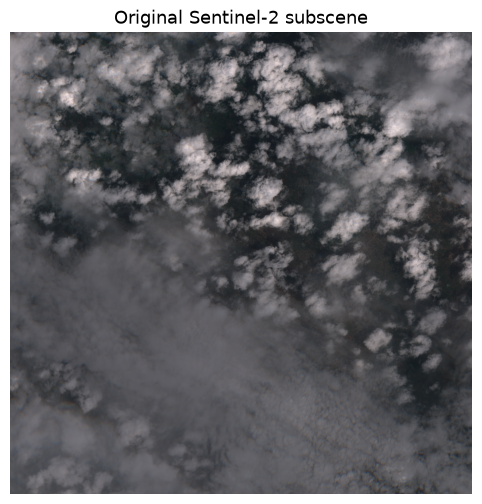

In [4]:
image = np.load(image_path)
rgb = image[:, :, [3, 2, 1]]

print("Scene name:", scene_name)
plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"Original Sentinel-2 subscene", fontsize=13)
plt.axis("off")
plt.show()

## 3. Inspecting the original one-hot mask (input)

The original mask is stored as three separate boolean layers: Clear, Cloud, and Cloud Shadow. 
Each pixel belongs to one of these three classes.

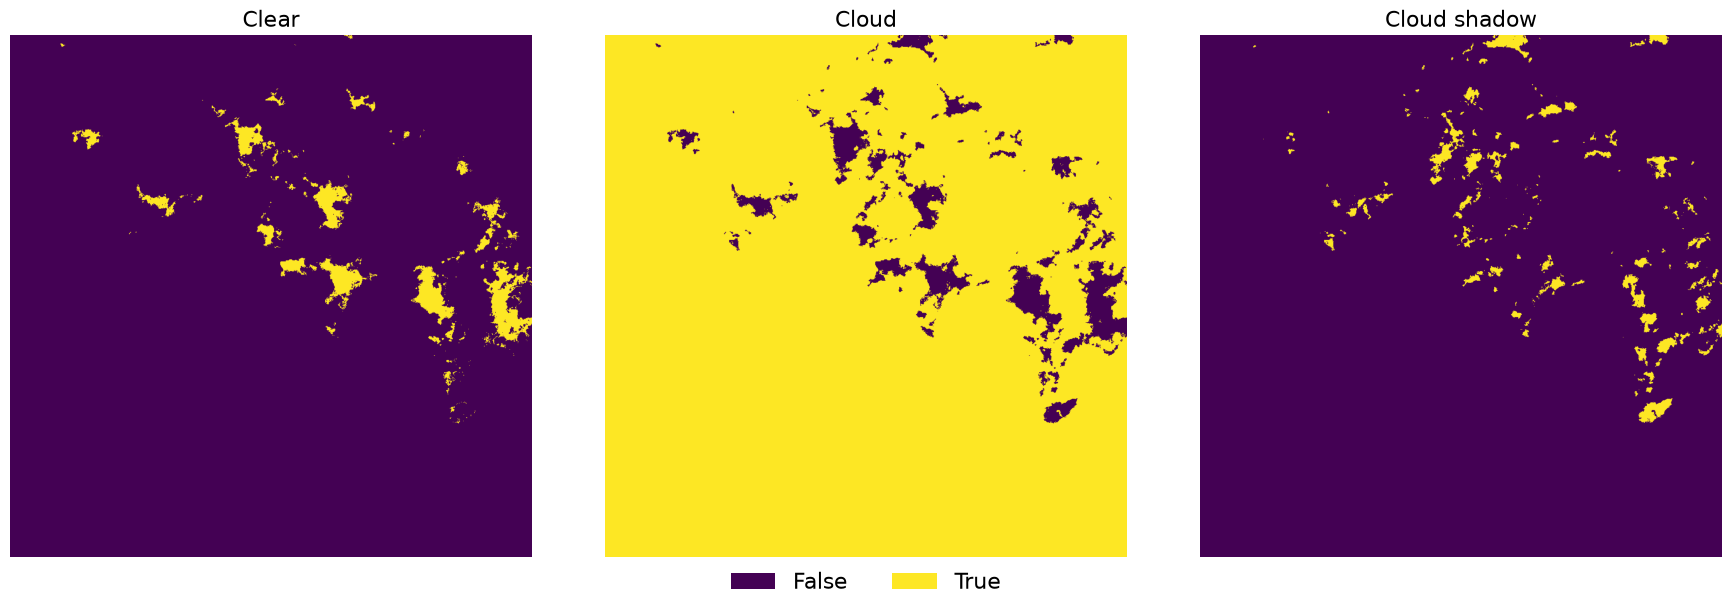

In [5]:
mask_one_hot = np.load(mask_path)
class_names = ["Clear", "Cloud", "Cloud shadow"]

fig, axes = plt.subplots(
    1,
    mask_one_hot.shape[-1],
    figsize=(18, 6),
)

for class_index, ax in enumerate(axes):
    ax.imshow(
        mask_one_hot[:, :, class_index],
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    ax.set_title(class_names[class_index], fontsize=16)
    ax.axis("off")

legend_elements = [
    Patch(facecolor="#440154", label="False"),
    Patch(facecolor="#fde725", label="True"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    fontsize=16,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 4. Converting the mask to class IDs

Original one-hot mask shape: (1022, 1022, 3)
Class-ID mask shape: (1022, 1022)
Classes present: [0 1 2]


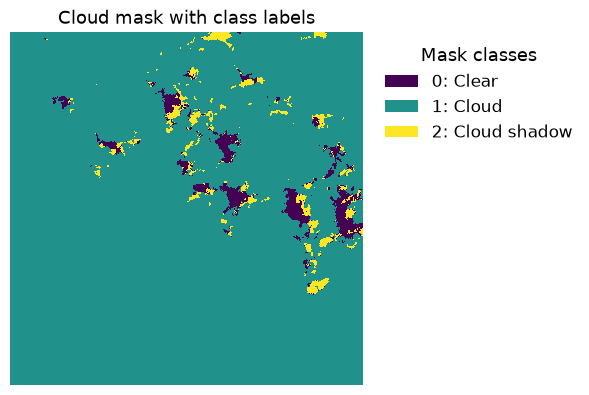

In [6]:
mask_class_ids = one_hot_to_class_ids(mask_one_hot)

print("Original one-hot mask shape:", mask_one_hot.shape)
print("Class-ID mask shape:", mask_class_ids.shape)
print("Classes present:", np.unique(mask_class_ids))

class_names = ["Clear", "Cloud", "Cloud shadow"]

# Three colors, one for each class
mask_colors = ["#440154", "#21918c", "#fde725"]
mask_cmap = ListedColormap(mask_colors)

plt.figure(figsize=(6, 6))

plt.imshow(mask_class_ids,cmap=mask_cmap,interpolation="nearest")

legend_elements = [
    Patch(
        facecolor=mask_colors[class_id],
        label=f"{class_id}: {class_name}",
    )
    for class_id, class_name in enumerate(class_names)
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=12,
    title="Mask classes",
    title_fontsize=13,
    frameon=False,
)

plt.title("Cloud mask with class labels",fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Padding the image and mask & Splitting the data into tiles

We want all images and masks in the final dataset to have a consistent tile size of 512 × 512 pixels. The original Sentinel-2 subscenes have dimensions of 1022 × 1022 pixels, which are not evenly divisible by 512. Therefore, both the subscene and its corresponding mask are padded before being split into tiles.

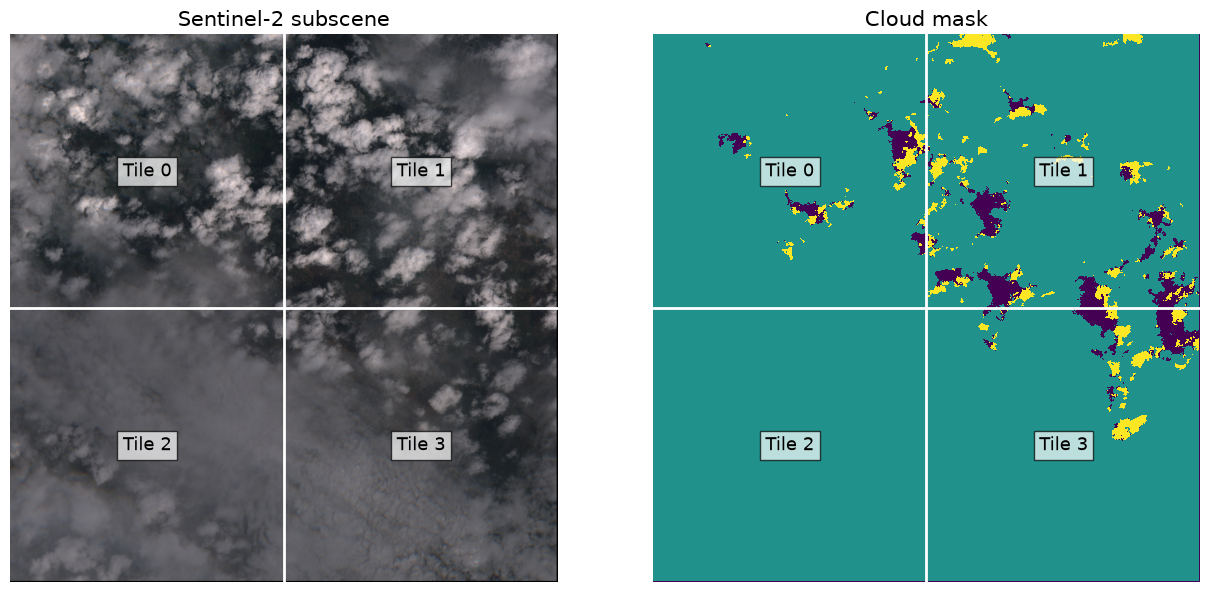

In [7]:
original_pixel_mask = np.ones(mask_class_ids.shape,dtype=bool)

tile_size = 512

padded_image = pad_to_tile_size(image, tile_size=tile_size)
padded_mask = pad_to_tile_size(mask_class_ids, tile_size=tile_size)
padded_original_pixel_mask = pad_to_tile_size(original_pixel_mask,tile_size=tile_size)
padded_rgb = padded_image[:, :, [3, 2, 1]]


image_tiles = list(split_into_tiles(padded_image, tile_size=tile_size))
mask_tiles = list(split_into_tiles(padded_mask, tile_size=tile_size))
original_pixel_tiles = list(split_into_tiles(padded_original_pixel_mask,tile_size=tile_size))


fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ---------------- Image ----------------
axes[0].imshow(padded_rgb)

for position in range(tile_size, padded_image.shape[0], tile_size):
    axes[0].axhline(position - 0.5, linewidth=2, color="white")

for position in range(tile_size, padded_image.shape[1], tile_size):
    axes[0].axvline(position - 0.5, linewidth=2, color="white")

for tile_index, (_, row_start, col_start) in enumerate(image_tiles):
    axes[0].text(
        col_start + tile_size / 2,
        row_start + tile_size / 2,
        f"Tile {tile_index}",
        ha="center",
        va="center",
        fontsize=13,
        bbox={"facecolor": "white", "alpha": 0.7},
    )

axes[0].set_title("Sentinel-2 subscene", fontsize=15)
axes[0].axis("off")


# ---------------- Mask ----------------
axes[1].imshow(padded_mask,cmap=mask_cmap,interpolation="nearest")

for position in range(tile_size, padded_mask.shape[0], tile_size):
    axes[1].axhline(position - 0.5, linewidth=2, color="white")

for position in range(tile_size, padded_mask.shape[1], tile_size):
    axes[1].axvline(position - 0.5, linewidth=2, color="white")

for tile_index, (_, row_start, col_start) in enumerate(mask_tiles):
    axes[1].text(
        col_start + tile_size / 2,
        row_start + tile_size / 2,
        f"Tile {tile_index}",
        ha="center",
        va="center",
        fontsize=13,
        bbox={"facecolor": "white", "alpha": 0.7},
    )

axes[1].set_title("Cloud mask", fontsize=15)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Calculating cloud coverage

In [8]:
tile_results = []

for tile_index, (
    (mask_tile, row_start, col_start),
    (original_pixel_tile, _, _),
) in enumerate(zip(mask_tiles, original_pixel_tiles)):

    cloud_coverage = calculate_cloud_coverage(mask_tile,original_pixel_tile)

    tile_results.append(
        {
            "tile": tile_index,
            "row_start": row_start,
            "column_start": col_start,
            "cloud_coverage_percent": cloud_coverage,
        }
    )

tile_results_df = pd.DataFrame(tile_results)
tile_results_df

,tile,row_start,column_start,cloud_coverage_percent
0,0,0,0,96.230316
1,1,0,512,88.593367
2,2,512,0,100.000000
3,3,512,512,94.801230


## 8. Loading the processed dataset (outputs)

In [9]:
output_directory = project_directory / "output"

image_output_directory = output_directory / "images"
mask_output_directory = output_directory / "masks"
metadata_output_directory = output_directory / "metadata"

dataset_format = NumpyDatasetFormat(
    images_directory=image_output_directory,
    masks_directory=mask_output_directory,
)

row_start = 0
col_start = 0

file_name = f"{scene_name}_r{row_start}_c{col_start}.npy"

saved_image = dataset_format.load_image(file_name)
saved_mask = dataset_format.load_mask(file_name)

print("Saved image:", file_name)
print("  Shape:", saved_image.shape)
print("  Data type:", saved_image.dtype)
print("  Minimum:", saved_image.min())
print("  Maximum:", saved_image.max())

print("\nSaved mask:", file_name)
print("  Shape:", saved_mask.shape)
print("  Data type:", saved_mask.dtype)
print("  Classes:", np.unique(saved_mask))

Saved image: S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_20180101T111527_r0_c0.npy
  Shape: (512, 512, 13)
  Data type: uint16
  Minimum: 38
  Maximum: 11552

Saved mask: S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_20180101T111527_r0_c0.npy
  Shape: (512, 512)
  Data type: uint8
  Classes: [0 1 2]


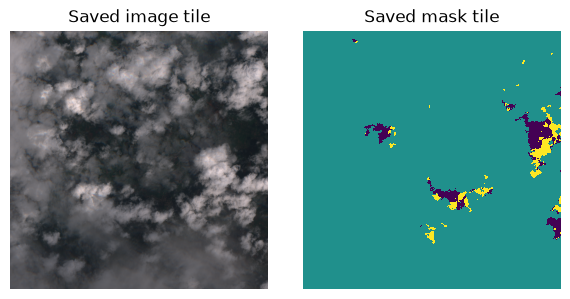

In [10]:
# Load only the RGB bands from the processed image
saved_rgb = dataset_format.load_image(file_name,bands=[3, 2, 1])

# Convert the stored integer values back to reflectance for display
saved_rgb = saved_rgb.astype(np.float32) / 10_000

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(saved_rgb)
axes[0].set_title("Saved image tile")
axes[0].axis("off")

axes[1].imshow(
    saved_mask,
    vmin=0,
    vmax=len(class_names) - 1,
    interpolation="nearest",
)
axes[1].set_title("Saved mask tile")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 9. Inspecting the generated metadata

In [15]:
tiles_metadata_path = metadata_output_directory / "tiles.csv"
dataset_metadata_path = metadata_output_directory / "dataset.json"

if tiles_metadata_path.exists():
    tiles_metadata = pd.read_csv(tiles_metadata_path)
    display(tiles_metadata.head())
else:
    print("tiles.csv was not found.")

if dataset_metadata_path.exists():
    with dataset_metadata_path.open("r", encoding="utf-8") as file:
        dataset_metadata = json.load(file)

    display(dataset_metadata)
else:
    print("dataset.json was not found.")

,tile_id,image_filename,mask_filename,product_id,row_start,column_start,cloud_coverage_percent
0,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,0,0,100.000000
1,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,0,512,100.000000
2,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,512,0,100.000000
3,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,S2A_MSIL1C_20180101T010721_N0206_R045_T53HLD_2...,512,512,100.000000
4,S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_2...,S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_2...,S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_2...,S2A_MSIL1C_20180101T074231_N0206_R049_T37LDJ_2...,0,0,96.230316


{'processed_spatial_resolution_m': 20,
 'class_mapping': {'CLEAR': 0, 'CLOUD': 1, 'CLOUD_SHADOW': 2},
 'bands': [{'band_id': 0,
   'band_name': 'B1',
   'center_wavelength_nm': 443,
   'bandwidth_nm': 20,
   'spatial_resolution_m': 60,
   'purpose': 'Atmospheric correction (aerosol scattering)'},
  {'band_id': 1,
   'band_name': 'B2',
   'center_wavelength_nm': 490,
   'bandwidth_nm': 65,
   'spatial_resolution_m': 10,
   'purpose': 'Sensitive to vegetation senescing, carotenoid, browning and soil background; atmospheric correction (aerosol scattering)'},
  {'band_id': 2,
   'band_name': 'B3',
   'center_wavelength_nm': 560,
   'bandwidth_nm': 35,
   'spatial_resolution_m': 10,
   'purpose': 'Green peak, sensitive to total chlorophyll in vegetation'},
  {'band_id': 3,
   'band_name': 'B4',
   'center_wavelength_nm': 665,
   'bandwidth_nm': 30,
   'spatial_resolution_m': 10,
   'purpose': 'Maximum chlorophyll absorption'},
  {'band_id': 4,
   'band_name': 'B5',
   'center_wavelength_nm'